Project Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on a retail sales dataset to understand sales performance, customer behavior, product category trends, and overall business patterns.

This project aims to clean and analyze the dataset, calculate descriptive statistics, study sales trends over time, analyze customer and product information, and create visualizations such as bar charts, line charts, and heatmaps.

The final goal is to identify useful insights from the data and provide actionable recommendations that can help the retail business make better data-driven decisions.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving retail_sales_dataset.csv to retail_sales_dataset.csv


Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Data Cleaning


In [ ]:
df = pd.read_csv("retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
df.shape

(1000, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [ ]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [ ]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

Descriptive Statistics

In [ ]:
df['Total Amount'].sum()

np.int64(456000)

In [ ]:
df['Total Amount'].mean()

np.float64(456.0)

In [ ]:
df['Total Amount'].max()

2000

In [ ]:
df['Total Amount'].min()

25

In [ ]:
df['Total Amount'].median()

135.0

In [ ]:
df['Total Amount'].std()

559.997631555123

Sales Analysis

In [ ]:
category_sales = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
category_sales

,Total Amount
Product Category,
Electronics,156905
Clothing,155580
Beauty,143515


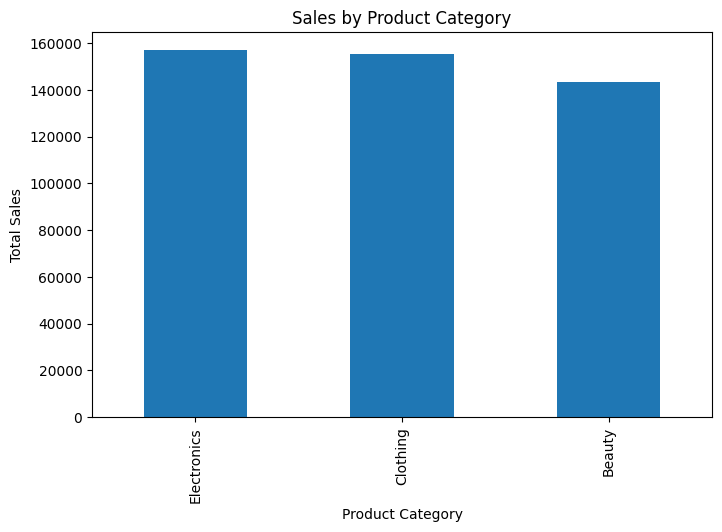

In [ ]:
plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')
plt.title("Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.show()

In [ ]:
daily_sales = df.groupby('Date')['Total Amount'].sum()
daily_sales

,Total Amount
Date,
2023-01-01,3600
2023-01-02,1765
2023-01-03,600
2023-01-04,1240
2023-01-05,1100
...,...
2023-12-27,700
2023-12-28,2075
2023-12-29,3400


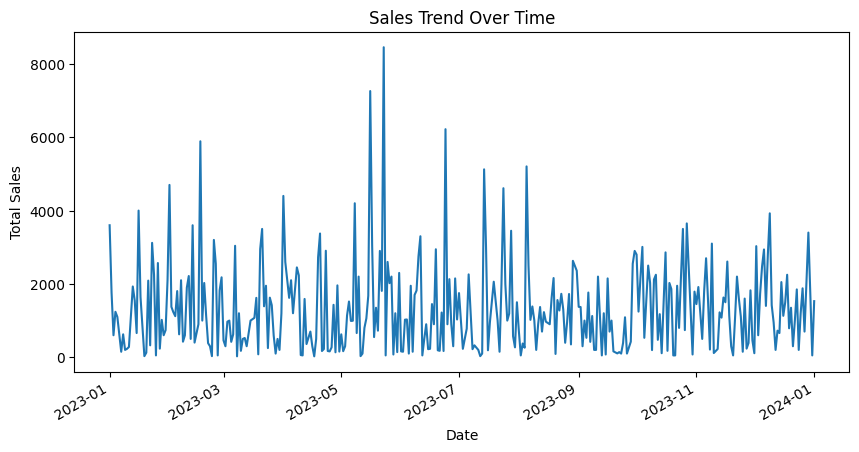

In [ ]:
plt.figure(figsize=(10,5))
daily_sales.plot(kind='line')
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()

In [ ]:
gender_sales = df.groupby('Gender')['Total Amount'].sum()
gender_sales

,Total Amount
Gender,
Female,232840
Male,223160


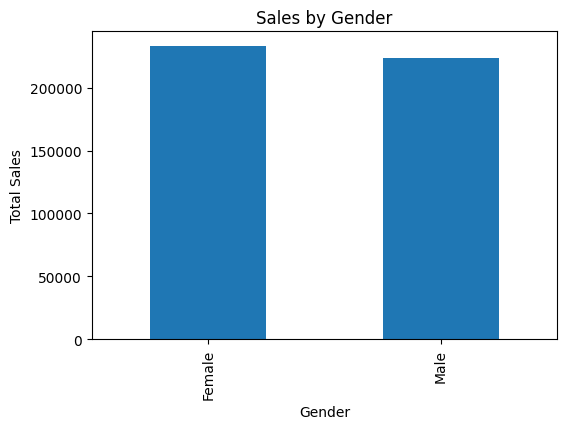

In [ ]:
plt.figure(figsize=(6,4))
gender_sales.plot(kind='bar')
plt.title("Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales")
plt.show()

Customer Analysis

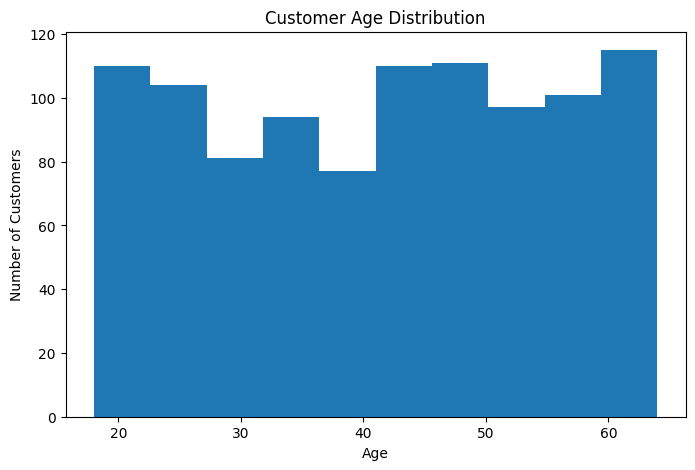

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=10)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

Product Analysis

In [ ]:
quantity_by_category = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)
quantity_by_category

,Quantity
Product Category,
Clothing,894
Electronics,849
Beauty,771


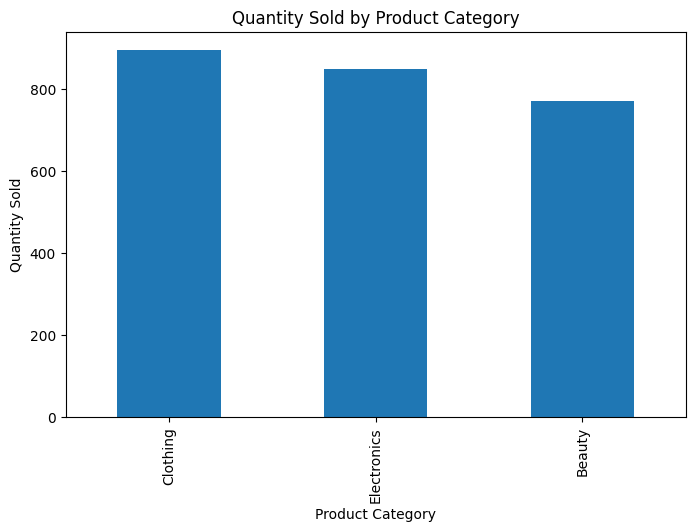

In [ ]:
plt.figure(figsize=(8,5))
quantity_by_category.plot(kind='bar')
plt.title("Quantity Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Quantity Sold")
plt.show()

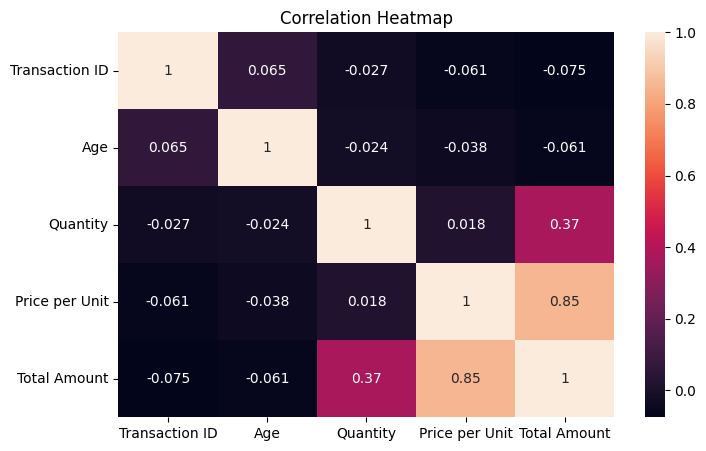

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

Insights:

1. The dataset contains 1000 transactions and 9 columns, including Date, Customer ID, Gender, Age, Product Category, Quantity, Price per Unit, and Total Amount.

2. The dataset is clean because there are no missing values and no duplicate records.

3. The total sales generated from the dataset are 456,000.

4. The average transaction amount is 456, while the median transaction amount is 135. This shows that some high-value transactions increase the average sales value.

5. The maximum transaction amount is 2,000 and the minimum transaction amount is 25.

6. Electronics generated the highest sales with 156,905, followed closely by Clothing with 155,580. Beauty generated 143,515 in sales.

7. Clothing had the highest quantity sold with 894 units, followed by Electronics with 849 units and Beauty with 771 units.

8. Female customers generated slightly higher sales, with 232,840, compared to male customers, who generated 223,160.

9. The sales trend over time shows that sales vary across different dates, which means the business should monitor sales patterns regularly.

10. The heatmap helps show the relationship between numerical variables such as Age, Quantity, Price per Unit, and Total Amount.

Recommendations:

1. The business should focus more on Electronics because it generated the highest total sales.

2. Clothing should also receive strong attention because it had the highest quantity sold and almost the same sales value as Electronics.

3. Inventory should be managed carefully for high-demand categories such as Clothing and Electronics to avoid stock shortages.

4. Since female customers generated slightly higher sales, the business can create targeted marketing campaigns for female customers while still maintaining balanced campaigns for male customers.

5. The business should analyze monthly and seasonal sales trends to identify high-sales and low-sales periods.

6. During low-sales periods, the business can offer discounts, promotions, or bundle offers to increase revenue.

7. The company should continue using data analysis to understand customer behavior, product performance, and sales trends for better business decisions.

Conclusion:

In this project, exploratory data analysis was performed on a retail sales dataset to understand sales performance, customer behavior, product category performance, and sales trends over time.

The dataset was first loaded and checked for missing values and duplicate records. The analysis showed that the dataset was clean, with no missing values and no duplicate entries. Descriptive statistics were calculated to understand the overall distribution of sales, quantity, price, and customer age.

The analysis found that Electronics generated the highest total sales, while Clothing had the highest quantity sold. Female customers contributed slightly more to total sales than male customers. Sales trends over time were also analyzed using a line chart, and a heatmap was used to understand relationships between numerical variables.

Overall, this project helped identify important patterns and insights from the retail sales data. These insights can help the business improve inventory planning, focus on high-performing product categories, create better marketing strategies, and make more data-driven business decisions.